# This project demonstrates a scalable web scraping pipeline that extracts structured data from a paginated website, stores raw HTML for reproducibility, and performs exploratory data analysis using Python.

In [5]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import time

In [6]:
actual_url = "https://www.scrapethissite.com/pages/forms/?page_num=1"

page_count = 1
headers = {"User-Agent": "Mozilla/5.0"}

while True:

    url = f"https://www.scrapethissite.com/pages/forms/?page_num={page_count}"
    
    res = requests.get(url , headers = headers)
    
    if res.status_code == 200:
        print(f"success status code of page =  {page_count}")
        soup = BeautifulSoup( res.text, "lxml")

        rows = soup.select("tr.team")

        if not rows:
            print("no pages anymore .....")
            break
                
        with open (f"web_scraping_2_raw_files/raw_file{page_count}.html" , 'w' , encoding= "utf-8") as f:
            f.write(res.text)
            print(f"Write to page number .... {page_count}")
            
    else:
        print(f"Failed to fetch.... page no = {page_count}")
        break
    
    page_count+= 1
    time.sleep(1)

success status code of page =  1
Write to page number .... 1
success status code of page =  2
Write to page number .... 2
success status code of page =  3
Write to page number .... 3
success status code of page =  4
Write to page number .... 4
success status code of page =  5
Write to page number .... 5
success status code of page =  6
Write to page number .... 6
success status code of page =  7
Write to page number .... 7
success status code of page =  8
Write to page number .... 8
success status code of page =  9
Write to page number .... 9
success status code of page =  10
Write to page number .... 10
success status code of page =  11
Write to page number .... 11
success status code of page =  12
Write to page number .... 12
success status code of page =  13
Write to page number .... 13
success status code of page =  14
Write to page number .... 14
success status code of page =  15
Write to page number .... 15
success status code of page =  16
Write to page number .... 16
success st

In [7]:
data = []

def safe_int(tag):
    return int(tag.text.strip()) if tag and tag.text.strip() else None

def safe_float(tag):
    return float(tag.text.strip()) if tag and tag.text.strip() else None


for i in range(1, 25):

    with open(f"web_scraping_2_raw_files/raw_file{i}.html", 'r', encoding="utf-8") as file:
        soup = BeautifulSoup(file.read(), "lxml")

        rows = soup.select("tr.team")

    for row in rows:
        data.append({
            "Name": row.select_one("td.name").text.strip(),
            "Year": safe_int(row.select_one("td.year")),
            "Wins": safe_int(row.select_one("td.wins")),
            "Losses": safe_int(row.select_one("td.losses")),
            "Win %": safe_float(row.select_one("td.pct")),
            "Goals For": safe_int(row.select_one("td.gf")),
            "Goals Against": safe_int(row.select_one("td.ga")),
            "+/-": safe_int(row.select_one("td.diff"))
        })

In [ ]:
data

In [8]:
df = pd.DataFrame(data)

In [9]:
df.shape

(582, 8)

In [10]:
df.head(2)

,Name,Year,Wins,Losses,Win %,Goals For,Goals Against,+/-
0,Boston Bruins,1990,44,24,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,0.388,292,278,14


In [11]:
df.isnull().sum()

Name             0
Year             0
Wins             0
Losses           0
Win %            0
Goals For        0
Goals Against    0
+/-              0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           582 non-null    object 
 1   Year           582 non-null    int64  
 2   Wins           582 non-null    int64  
 3   Losses         582 non-null    int64  
 4   Win %          582 non-null    float64
 5   Goals For      582 non-null    int64  
 6   Goals Against  582 non-null    int64  
 7   +/-            582 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 36.5+ KB


In [13]:
df.Name.unique()

array(['Boston Bruins', 'Buffalo Sabres', 'Calgary Flames',
       'Chicago Blackhawks', 'Detroit Red Wings', 'Edmonton Oilers',
       'Hartford Whalers', 'Los Angeles Kings', 'Minnesota North Stars',
       'Montreal Canadiens', 'New Jersey Devils', 'New York Islanders',
       'New York Rangers', 'Philadelphia Flyers', 'Pittsburgh Penguins',
       'Quebec Nordiques', 'St. Louis Blues', 'Toronto Maple Leafs',
       'Vancouver Canucks', 'Washington Capitals', 'Winnipeg Jets',
       'San Jose Sharks', 'Ottawa Senators', 'Tampa Bay Lightning',
       'Mighty Ducks of Anaheim', 'Dallas Stars', 'Florida Panthers',
       'Colorado Avalanche', 'Phoenix Coyotes', 'Carolina Hurricanes',
       'Nashville Predators', 'Atlanta Thrashers',
       'Columbus Blue Jackets', 'Minnesota Wild', 'Anaheim Ducks'],
      dtype=object)

# Best team for each Year

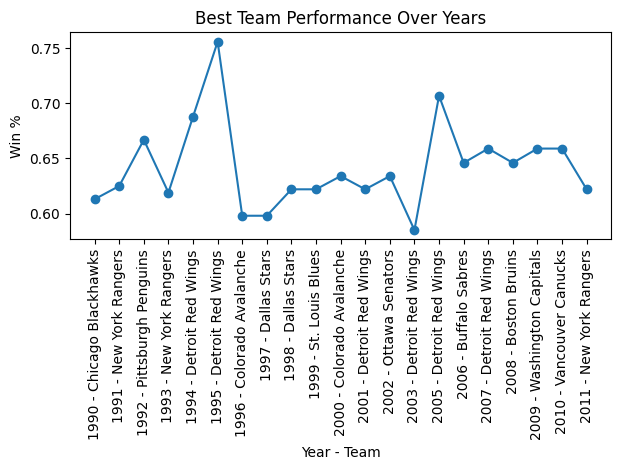

In [25]:
labels = best_per_year['Year'].astype(str) + " - " + best_per_year['Name']

plt.figure()
plt.plot(labels, best_per_year['Win %'], marker='o')
plt.xticks(rotation=90)
plt.xlabel("Year - Team")
plt.ylabel("Win %")
plt.title("Best Team Performance Over Years")
plt.tight_layout()
plt.show()

In [15]:
best_per_year = df.loc[df.groupby("Year")["Win %"].idxmax()]
print(best_per_year[["Year", "Name", "Win %"]])

     Year                 Name  Win %
3    1990   Chicago Blackhawks  0.613
33   1991     New York Rangers  0.625
58   1992  Pittsburgh Penguins  0.667
81   1993     New York Rangers  0.619
99   1994    Detroit Red Wings  0.688
126  1995    Detroit Red Wings  0.756
150  1996   Colorado Avalanche  0.598
178  1997         Dallas Stars  0.598
204  1998         Dallas Stars  0.622
247  1999      St. Louis Blues  0.622
260  2000   Colorado Avalanche  0.634
292  2001    Detroit Red Wings  0.622
332  2002      Ottawa Senators  0.634
352  2003    Detroit Red Wings  0.585
382  2005    Detroit Red Wings  0.707
405  2006       Buffalo Sabres  0.646
442  2007    Detroit Red Wings  0.659
464  2008        Boston Bruins  0.646
521  2009  Washington Capitals  0.659
550  2010    Vancouver Canucks  0.659
570  2011     New York Rangers  0.622


# top teams with maximun wins 

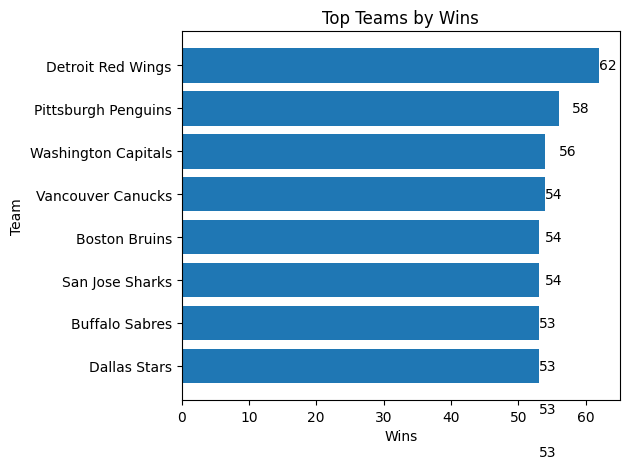

In [26]:
top_wins = df.sort_values('Wins', ascending=False).head(10)

plt.figure()
plt.barh(top_wins['Name'], top_wins['Wins'])

for i, value in enumerate(top_wins['Wins']):
    plt.text(value, i, str(value), va='center')

plt.xlabel("Wins")
plt.ylabel("Team")
plt.title("Top Teams by Wins")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
# top teams with maximun wins 

df.sort_values('Wins' , ascending=False).head(10)

,Name,Year,Wins,Losses,Win %,Goals For,Goals Against,+/-
126,Detroit Red Wings,1995,62,13,0.756,325,181,144
382,Detroit Red Wings,2005,58,16,0.707,305,209,96
58,Pittsburgh Penguins,1992,56,21,0.667,367,268,99
521,Washington Capitals,2009,54,15,0.659,318,233,85
550,Vancouver Canucks,2010,54,19,0.659,262,185,77
442,Detroit Red Wings,2007,54,21,0.659,257,184,73
464,Boston Bruins,2008,53,19,0.646,274,196,78
486,San Jose Sharks,2008,53,18,0.646,257,204,53
405,Buffalo Sabres,2006,53,22,0.646,308,242,66
381,Dallas Stars,2005,53,23,0.646,265,218,47


# Wins vs Losses

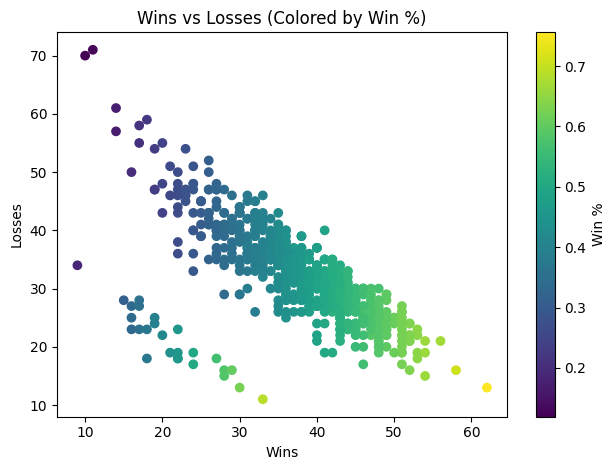

In [27]:
plt.figure()
scatter = plt.scatter(df['Wins'], df['Losses'], c=df['Win %'])

plt.xlabel("Wins")
plt.ylabel("Losses")
plt.title("Wins vs Losses (Colored by Win %)")

plt.colorbar(scatter, label="Win %")

plt.tight_layout()
plt.show()

# Goal Difference Distribution

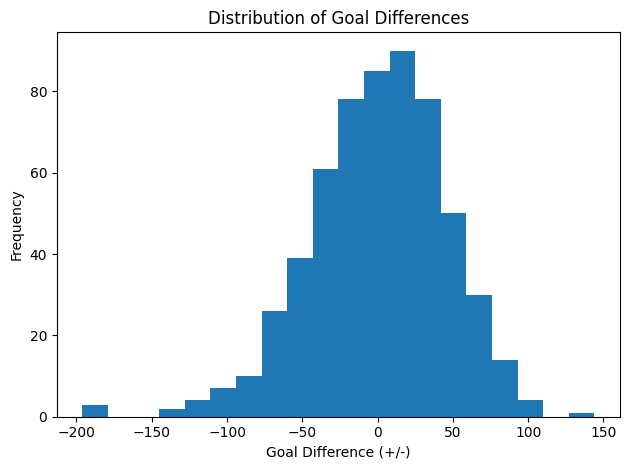

In [21]:
plt.figure()
plt.hist(df['+/-'], bins=20)
plt.xlabel("Goal Difference (+/-)")
plt.ylabel("Frequency")
plt.title("Distribution of Goal Differences")

plt.tight_layout()
plt.show()

# top 10 teams with maximun losses 

In [15]:
# top 10 teams with maximun losses 

df.sort_values('Losses' , ascending=False).head(10)

,Name,Year,Wins,Losses,Win %,Goals For,Goals Against,+/-
60,San Jose Sharks,1992,11,71,0.131,218,414,-196
56,Ottawa Senators,1992,10,70,0.119,202,395,-193
82,Ottawa Senators,1993,14,61,0.167,201,397,-196
135,Ottawa Senators,1995,18,59,0.220,191,291,-100
37,San Jose Sharks,1991,17,58,0.212,219,359,-140
225,Atlanta Thrashers,1999,14,57,0.171,170,313,-143
193,Tampa Bay Lightning,1997,17,55,0.207,151,269,-118
138,San Jose Sharks,1995,20,55,0.244,252,357,-105
62,Tampa Bay Lightning,1992,23,54,0.274,245,332,-87
220,Tampa Bay Lightning,1998,19,54,0.232,179,292,-113


In [22]:
df.to_csv('web_scrapping_2_full.csv ', index= False)